In [1]:
import numpy as np 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import qmc 

SEED = 42 
torch.manual_seed(SEED)
np.random.seed(SEED)

DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64) 



In [2]:
# --- problem definition ---
DELTA2 = 0.0025          # coefficient on u_xxx
X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX =  0.0, 1.0
L = X_MAX - X_MIN

# --- training config ---
N_F    = 18000           # residual (collocation) points
N_B    = 914             # boundary points (paired left/right)
N_0    = 512             # initial condition points
EPOCHS = 20000
LR     = 1e-3

print(f"device: {DEV}")

device: cuda


In [3]:
class Sine(nn.Module):
    def __init__(self, w0=1.0):
        super().__init__()
        self.w0 = w0
    def forward(self, x):
        return torch.sin(self.w0 * x)


class PINN(nn.Module):
    """10 hidden layers, 20 units, sine activation, SIREN init."""
    def __init__(self, layers=10, width=20, w0_first=5.0, w0=1.0):
        super().__init__()
        self.w0_first, self.w0 = w0_first, w0
        dims = [2] + [width] * layers + [1]
        self.lins = nn.ModuleList(
            [nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)]
        )
        self._siren_init()

    def _siren_init(self):
        with torch.no_grad():
            for i, lin in enumerate(self.lins):
                n_in = lin.in_features
                if i == 0:
                    b = 1.0 / n_in
                else:
                    b = np.sqrt(6.0 / n_in) / self.w0
                lin.weight.uniform_(-b, b)
                lin.bias.uniform_(-b, b)

    def forward(self, x, t):
        # normalize inputs to [-1,1] -- helps conditioning
        xs = 2.0 * (x - X_MIN) / L - 1.0
        ts = 2.0 * (t - T_MIN) / (T_MAX - T_MIN) - 1.0
        h = torch.cat([xs, ts], dim=1)
        for i, lin in enumerate(self.lins[:-1]):
            w = self.w0_first if i == 0 else self.w0
            h = torch.sin(w * lin(h))
        return self.lins[-1](h)


net = PINN().to(DEV)
print(sum(p.numel() for p in net.parameters()), "parameters")

3861 parameters


In [4]:
def sample_points():
    # --- residual points: LHS over the space-time domain ---
    eng = qmc.LatinHypercube(d=2, seed=SEED)
    s = eng.random(N_F)
    xf = X_MIN + s[:, 0:1] * L
    tf = T_MIN + s[:, 1:2] * (T_MAX - T_MIN)

    # --- initial condition points ---
    x0 = np.linspace(X_MIN, X_MAX, N_0).reshape(-1, 1)
    t0 = np.zeros_like(x0)
    u0 = np.cos(np.pi * x0)

    # --- boundary: paired left/right at same t, for periodicity ---
    n_pair = N_B // 2
    tb = np.random.rand(n_pair, 1) * (T_MAX - T_MIN) + T_MIN
    xbL = np.full_like(tb, X_MIN)
    xbR = np.full_like(tb, X_MAX)

    T = lambda a, rg=False: torch.tensor(a, device=DEV, requires_grad=rg)
    return dict(
        xf=T(xf, True), tf=T(tf, True),
        x0=T(x0), t0=T(t0), u0=T(u0),
        xbL=T(xbL, True), xbR=T(xbR, True), tb=T(tb, True),
    )

P = sample_points()
for k, v in P.items():
    print(f"{k:4s} {tuple(v.shape)}")

xf   (18000, 1)
tf   (18000, 1)
x0   (512, 1)
t0   (512, 1)
u0   (512, 1)
xbL  (457, 1)
xbR  (457, 1)
tb   (457, 1)


In [5]:
### step : residual and periodic BC via autograd

def d(y, x, order=1):
    """Repeated autograd derivative."""
    for _ in range(order):
        y = torch.autograd.grad(
            y, x, grad_outputs=torch.ones_like(y),
            create_graph=True
        )[0]
    return y


def pde_residual(net, x, t):
    u   = net(x, t)
    u_t = d(u, t, 1)
    u_x = d(u, x, 1)
    u_xxx = d(u_x, x, 2)          # 2 more -> third order total
    return u_t + u * u_x - DELTA2 * u_xxx


def periodic_loss(net, xL, xR, tb):
    """u and its first two x-derivatives must match across the period."""
    uL, uR = net(xL, tb), net(xR, tb)
    uLx, uRx = d(uL, xL, 1), d(uR, xR, 1)
    uLxx, uRxx = d(uLx, xL, 1), d(uRx, xR, 1)
    mse = nn.functional.mse_loss
    return mse(uL, uR) + mse(uLx, uRx) + mse(uLxx, uRxx)

In [6]:
### training loop (adam) 
W_F, W_0, W_B = 1.0, 100.0, 100.0    # loss weights

opt = torch.optim.Adam(net.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-5)
mse = nn.functional.mse_loss

hist = {"total": [], "f": [], "ic": [], "bc": []}

for ep in range(EPOCHS + 1):
    opt.zero_grad()

    r  = pde_residual(net, P["xf"], P["tf"])
    Lf = mse(r, torch.zeros_like(r))
    L0 = mse(net(P["x0"], P["t0"]), P["u0"])
    Lb = periodic_loss(net, P["xbL"], P["xbR"], P["tb"])

    loss = W_F * Lf + W_0 * L0 + W_B * Lb
    loss.backward()
    opt.step()
    sched.step()

    for k, v in zip(hist, [loss, Lf, L0, Lb]):
        hist[k].append(v.item())

    if ep % 500 == 0:
        print(f"{ep:5d}  total {loss.item():.3e} | "
              f"f {Lf.item():.3e}  ic {L0.item():.3e}  bc {Lb.item():.3e}")

d:\PINN\.venv\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    0  total 7.514e+04 | f 1.171e+01  ic 1.513e+00  bc 7.497e+02
  500  total 3.720e+01 | f 3.986e+00  ic 3.026e-01  bc 2.954e-02
 1000  total 1.670e+01 | f 4.526e+00  ic 1.077e-01  bc 1.401e-02
 1500  total 8.061e+00 | f 4.472e+00  ic 2.661e-02  bc 9.286e-03
 2000  total 5.192e+00 | f 3.599e+00  ic 1.086e-02  bc 5.079e-03
 2500  total 3.803e+00 | f 2.941e+00  ic 5.796e-03  bc 2.820e-03
 3000  total 2.978e+00 | f 2.453e+00  ic 3.477e-03  bc 1.772e-03
 3500  total 2.435e+00 | f 2.076e+00  ic 2.333e-03  bc 1.255e-03
 4000  total 2.056e+00 | f 1.789e+00  ic 1.736e-03  bc 9.342e-04
 4500  total 1.779e+00 | f 1.569e+00  ic 1.389e-03  bc 7.088e-04
 5000  total 1.568e+00 | f 1.397e+00  ic 1.160e-03  bc 5.451e-04
 5500  total 1.400e+00 | f 1.259e+00  ic 9.898e-04  bc 4.228e-04
 6000  total 1.261e+00 | f 1.143e+00  ic 8.482e-04  bc 3.282e-04
 6500  total 1.148e+00 | f 1.048e+00  ic 7.482e-04  bc 2.456e-04
 7000  total 2.058e+00 | f 9.526e-01  ic 7.496e-04  bc 1.030e-02
 7500  total 9.601e-01 | 

In [7]:
### L-BFGS polish 
lbfgs = torch.optim.LBFGS(
    net.parameters(), lr=1.0, max_iter=3000,
    tolerance_grad=1e-12, tolerance_change=1e-14,
    history_size=100, line_search_fn="strong_wolfe",
)

def closure():
    lbfgs.zero_grad()
    r = pde_residual(net, P["xf"], P["tf"])
    loss = (W_F * mse(r, torch.zeros_like(r))
            + W_0 * mse(net(P["x0"], P["t0"]), P["u0"])
            + W_B * periodic_loss(net, P["xbL"], P["xbR"], P["tb"]))
    loss.backward()
    return loss

lbfgs.step(closure)
print("after L-BFGS:", closure().item())

after L-BFGS: 0.16778244527299888


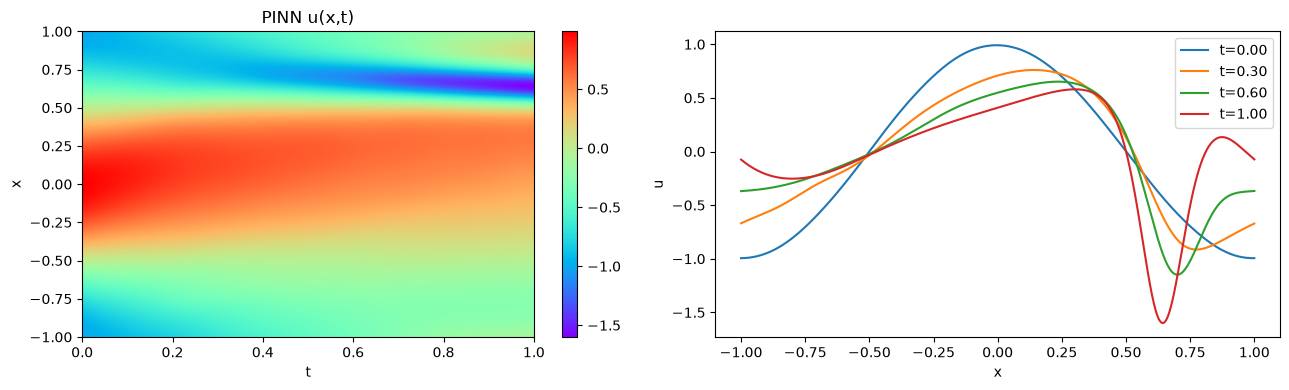

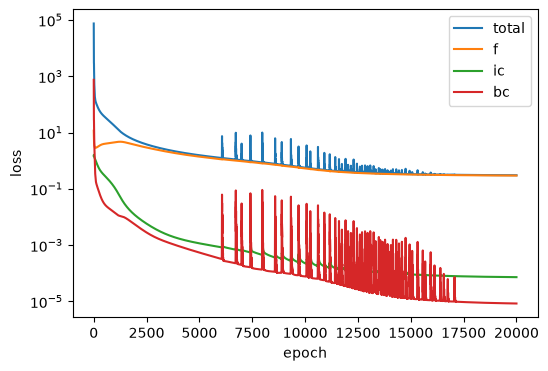

In [8]:
### evaluation and grids 
nx, nt = 512, 201
xg = np.linspace(X_MIN, X_MAX, nx)
tg = np.linspace(T_MIN, T_MAX, nt)
XX, TT = np.meshgrid(xg, tg, indexing="ij")

with torch.no_grad():
    xt = torch.tensor(XX.reshape(-1, 1), device=DEV)
    tt = torch.tensor(TT.reshape(-1, 1), device=DEV)
    U = net(xt, tt).cpu().numpy().reshape(nx, nt)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im = ax[0].imshow(U, extent=[T_MIN, T_MAX, X_MIN, X_MAX],
                  origin="lower", aspect="auto", cmap="rainbow")
ax[0].set_xlabel("t"); ax[0].set_ylabel("x"); ax[0].set_title("PINN u(x,t)")
plt.colorbar(im, ax=ax[0])

for tv in [0.0, 0.3, 0.6, 1.0]:
    j = np.argmin(abs(tg - tv))
    ax[1].plot(xg, U[:, j], label=f"t={tg[j]:.2f}")
ax[1].legend(); ax[1].set_xlabel("x"); ax[1].set_ylabel("u")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 4))
for k in hist:
    plt.semilogy(hist[k], label=k)
plt.legend(); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()

## **Ground Truth Solution**

In [9]:
import numpy as np

def kdv_spectral(N=512, T=1.0, nt_out=201, delta2=0.0025):
    """
    Solve u_t + u u_x = delta2 * u_xxx on x in [-1,1], periodic,
    via Fourier pseudospectral + ETDRK4 (Kassam-Trefethen).

    Linear part:    u_t = delta2 * u_xxx  ->  L = delta2 * (i k)^3 = i * delta2 * k^3
    Nonlinear part: -u u_x = -0.5 * (u^2)_x
    """
    Lx = 2.0
    x = np.linspace(-1, 1, N, endpoint=False)
    k = 2 * np.pi * np.fft.fftfreq(N, d=Lx / N)     # wavenumbers on [-1,1]

    u = np.cos(np.pi * x)
    v = np.fft.fft(u)

    L = 1j * delta2 * k**3          # since (ik)^3 = -i k^3, and RHS sign is +delta2
    L = -1j * delta2 * k**3 * -1    # keep explicit; see note below
    L = 1j * delta2 * k**3

    h = 1e-4 if T / 1e-4 < 2e6 else T / 200000
    nsteps = int(round(T / h))
    h = T / nsteps

    # --- ETDRK4 coefficients via contour integral (Kassam & Trefethen 2005) ---
    E  = np.exp(h * L)
    E2 = np.exp(h * L / 2)
    M  = 32
    r  = np.exp(1j * np.pi * (np.arange(1, M + 1) - 0.5) / M)
    LR = h * L[:, None] + r[None, :]

    Q  = h * np.real(np.mean((np.exp(LR / 2) - 1) / LR, axis=1))
    f1 = h * np.real(np.mean((-4 - LR + np.exp(LR) * (4 - 3 * LR + LR**2)) / LR**3, axis=1))
    f2 = h * np.real(np.mean((2 + LR + np.exp(LR) * (-2 + LR)) / LR**3, axis=1))
    f3 = h * np.real(np.mean((-4 - 3 * LR - LR**2 + np.exp(LR) * (4 - LR)) / LR**3, axis=1))

    g = -0.5j * k                                   # -(1/2) d/dx  in Fourier
    NL = lambda v: g * np.fft.fft(np.real(np.fft.ifft(v))**2)

    out_every = max(1, nsteps // (nt_out - 1))
    U = [np.real(np.fft.ifft(v)).copy()]
    tsave = [0.0]

    for n in range(1, nsteps + 1):
        Nv = NL(v)
        a  = E2 * v + Q * Nv;      Na = NL(a)
        b  = E2 * v + Q * Na;      Nb = NL(b)
        c  = E2 * a + Q * (2 * Nb - Nv);  Nc = NL(c)
        v  = E * v + Nv * f1 + 2 * (Na + Nb) * f2 + Nc * f3

        if n % out_every == 0 or n == nsteps:
            U.append(np.real(np.fft.ifft(v)).copy())
            tsave.append(n * h)

    return x, np.array(tsave), np.array(U).T     # U shape (N, nt)


x_ref, t_ref, U_ref = kdv_spectral()
print("reference:", U_ref.shape)

reference: (512, 201)


## **Compare PINN against reference**

relative L2 error: 6.1215e-01
max abs error:     1.7261e+00


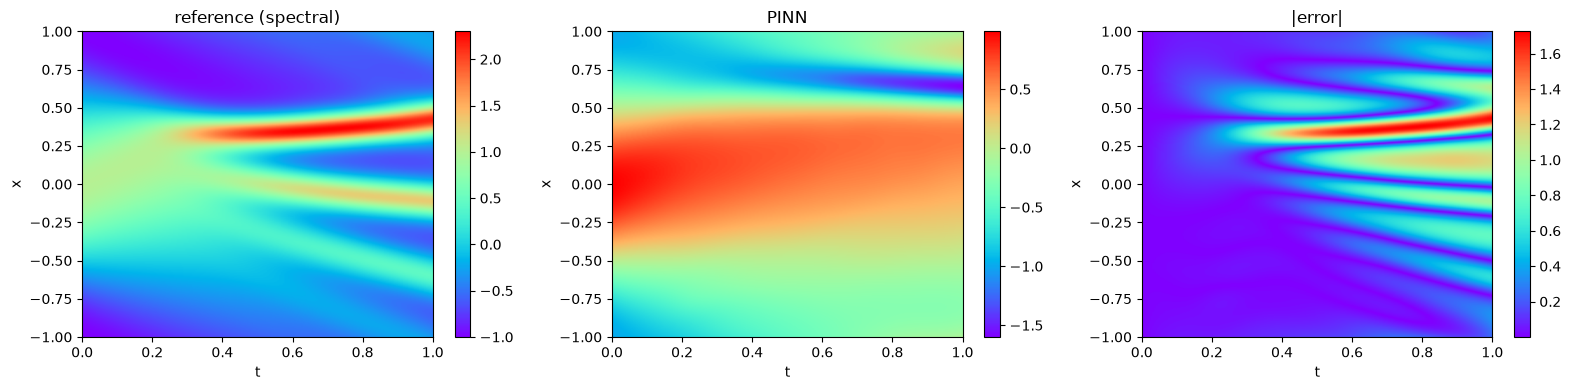

In [10]:
from scipy.interpolate import RegularGridInterpolator

# interpolate reference onto the PINN evaluation grid
interp = RegularGridInterpolator(
    (x_ref, t_ref), U_ref, bounds_error=False, fill_value=None
)
pts = np.stack([XX.ravel(), np.clip(TT.ravel(), t_ref[0], t_ref[-1])], axis=-1)
U_exact = interp(pts).reshape(nx, nt)

err = U - U_exact
rel_l2 = np.linalg.norm(err) / np.linalg.norm(U_exact)
print(f"relative L2 error: {rel_l2:.4e}")
print(f"max abs error:     {np.abs(err).max():.4e}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, dat, ttl in zip(ax, [U_exact, U, np.abs(err)],
                       ["reference (spectral)", "PINN", "|error|"]):
    im = a.imshow(dat, extent=[T_MIN, T_MAX, X_MIN, X_MAX],
                  origin="lower", aspect="auto", cmap="rainbow")
    a.set_title(ttl); a.set_xlabel("t"); a.set_ylabel("x")
    plt.colorbar(im, ax=a)
plt.tight_layout(); plt.show()